# 3 — Temporal entropies, the wall, and the entropy route to $c$

The temporal MPS that transverse contraction works with have their own entanglement — the
*generalised temporal entropy* $S_2 = -\log\mathrm{Tr}(\mathcal{T}_t^2)$ — and it plays two
roles at once. Practically, it controls the cost of the whole method. Physically, at a critical
quench it is itself conformal: for a temporal cut at time $t$ out of $T$,

- $\mathrm{Re}\,S_2$ follows the chord profile with slope $c/8$ in
  $W(t,T) = \ln\left[\tfrac{2T}{\pi}\sin\tfrac{\pi t}{T}\right]$;
- $\mathrm{Im}\,S_2$ forms an interior plateau at $\pi c/16 \approx 0.098$ for $c = 1/2$.

So the entropy is a second, independent route to the central charge — and this notebook is
also the story of where that route stops: the **wall**, the coupling-dependent time beyond
which the contraction no longer converges. Quantitative profiles at $p \neq 0$ come from the
corrected-column cluster arms (`_bulk` labels) under `data/cluster/`.

In [1]:
# load the library: model Hamiltonians, the temporal-MPO construction, the block power
# method, the entropy routines, and the plotting theme
include("../src/thesislib.jl")
using JLD2, Printf, Statistics
thesis_plot_theme!()

## The profiles, where everything works

The thesis figure `res_domes`, at $p = 0.1$: real part beside imaginary part at four times.
The dashed curves are the $c = 1/2$ chord profiles with the non-universal constant matched per
profile — the *shape* is the prediction. The imaginary plateau sits visibly above the
$\pi c/16$ line; that offset is the finite-time correction, and it decides the fate of this
route.

T= 6  plateau = 0.1285
T= 7  plateau = 0.1307


T= 8  plateau = 0.1287
T= 9  plateau = 0.1258
target πc/16 at c=1/2 = 0.0982


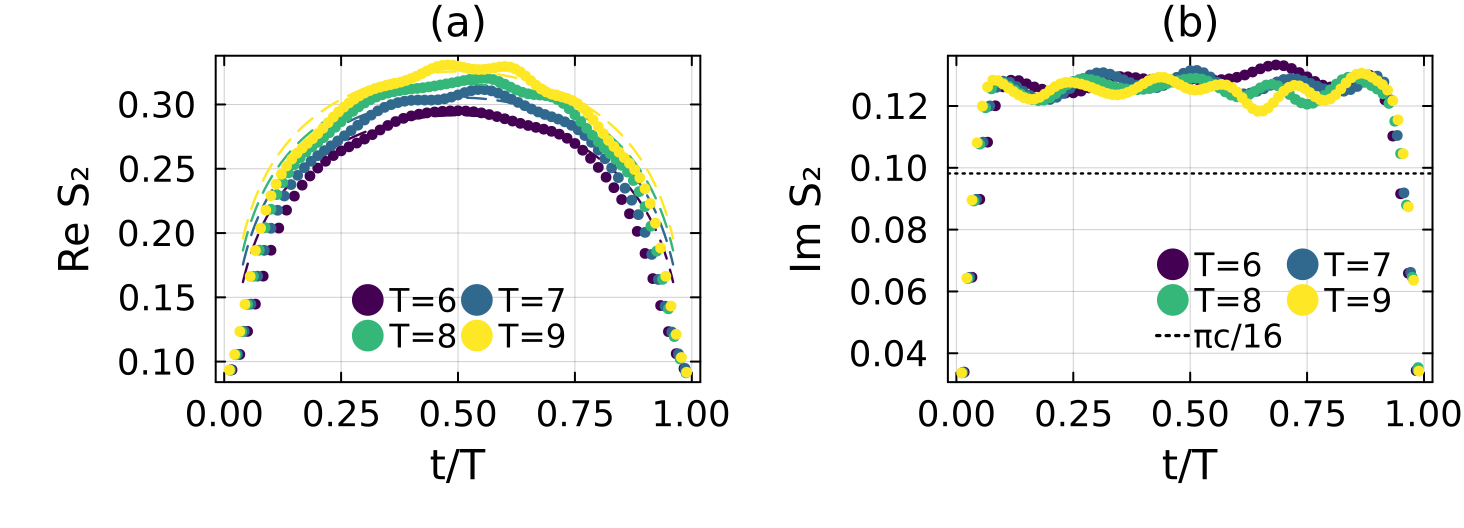

In [2]:
include("../scripts/figures/fig_domes.jl")
make_domes()

## The wall: why there is a maximal time at all

The contraction fails when the transfer-matrix gap closes: as $T$ grows, the second eigenvalue
approaches the first, the power iteration can no longer separate the leading eigenvector, and
the returned $(\langle L|, |R\rangle)$ pair is contaminated. The single-vector iteration is
the first casualty; the block method pushes the breakdown to later times but does not remove
it — halving $\chi$ does not move it, refining $\delta t$ does not move it. The wall is a
property of the operator, not of the solver.

The sweep below (from an early campaign on the **legacy column** — kept here as a qualitative
map, since the corrected column shifts numbers but not the phenomenon) shows both faces of it
across the coupling: the gap $|\lambda_1|/|\lambda_0| \to 1$, and the peak entropy bending
over at the same time. Read the wiggles at $p = 0.3$ and $p = 0.5$ as part of the map rather
than as physics: this is a four-state block, and at those points it cuts through the tower
instead of resolving it, which the block-size control in notebook 6 shows directly.

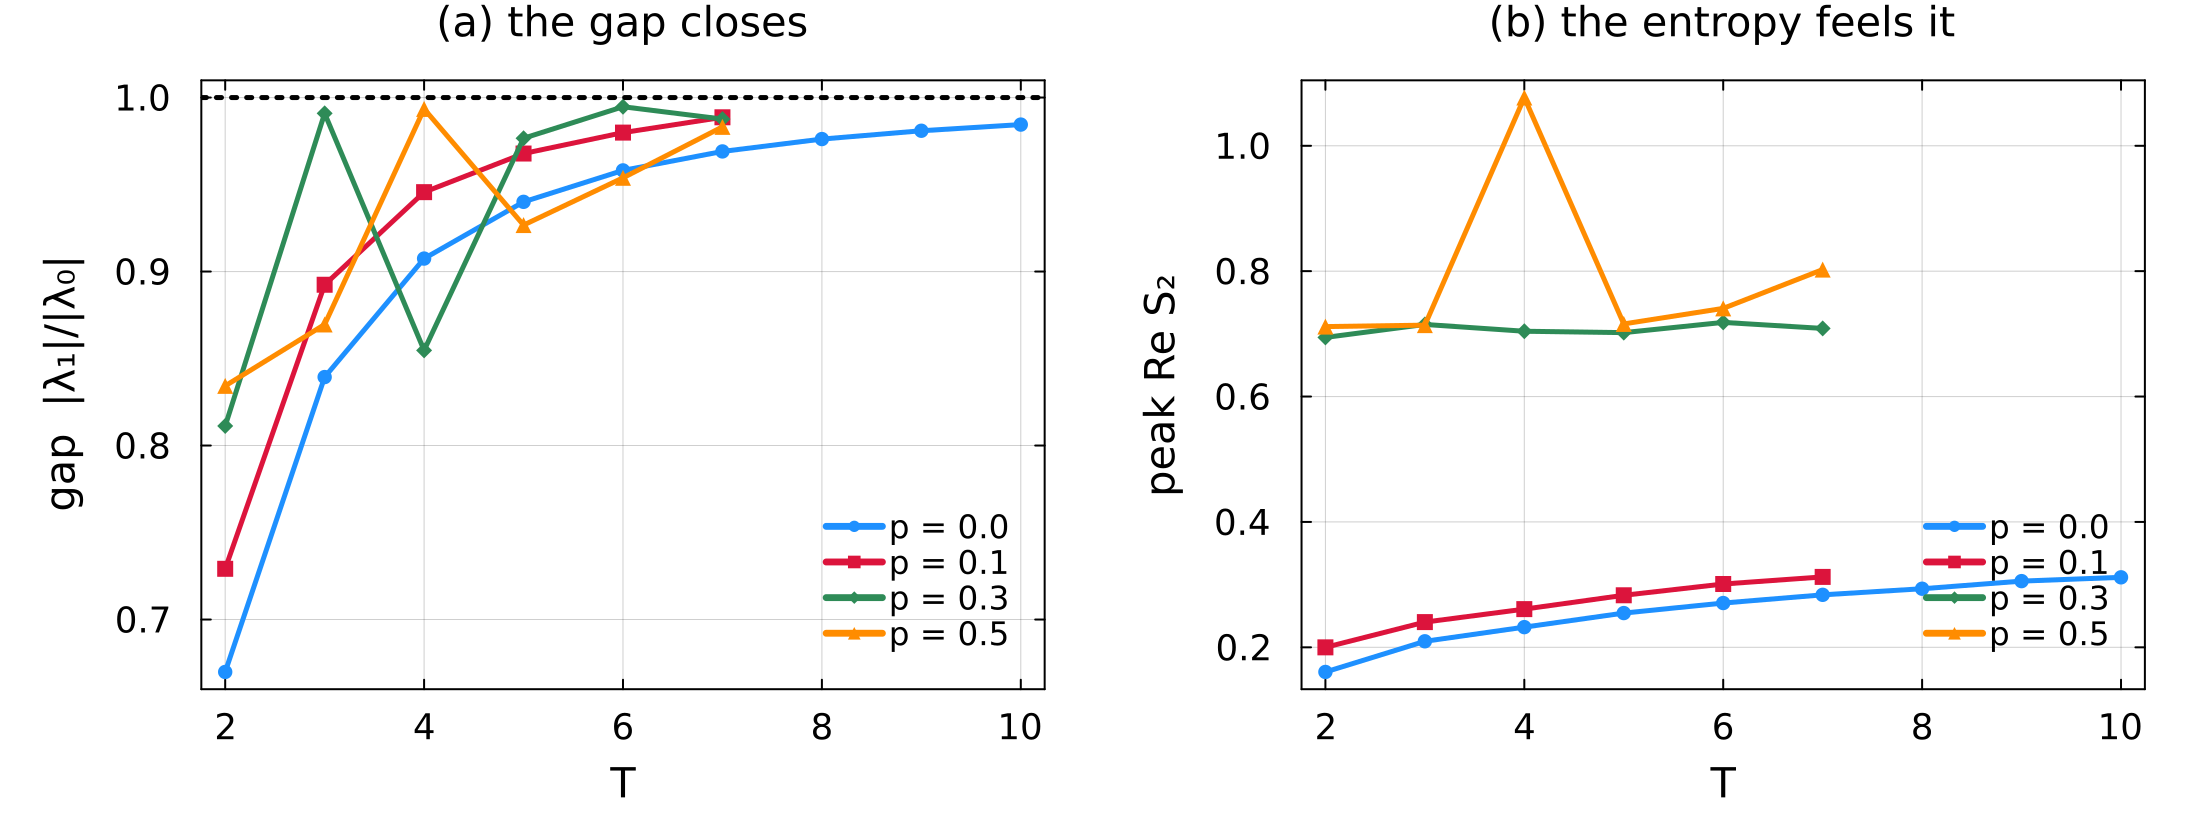

In [3]:
# qualitative map of the wall (legacy-column sweep, p-grid 0..0.5, k-block data)
D = load("../data/local/nb55_pgap.jld2", "D")
pg = plot(xlabel="T", ylabel="gap  |λ₁|/|λ₀|", legend=:bottomright, title="(a) the gap closes")
pe = plot(xlabel="T", ylabel="peak Re S₂", legend=:bottomright, title="(b) the entropy feels it")
for p in sort(collect(keys(D)))
    Ts = sort(collect(keys(D[p])))
    plot!(pg, Ts, [D[p][T].gap  for T in Ts], marker=P_MARKER[p], ms=4, msw=0,
          color=P_COLOR[p], label="p = $p")
    plot!(pe, Ts, [D[p][T].peak for T in Ts], marker=P_MARKER[p], ms=4, msw=0,
          color=P_COLOR[p], label="p = $p")
end
hline!(pg, [1.0], color=:black, ls=:dot, label="")
plot(pg, pe, layout=(1, 2), size=(1100, 420), margin=5Plots.mm)

The stronger the coupling, the earlier the gap closes and the earlier the entropy stops
being physical. That compression of the usable window — 15, 9, 7, 6 evolution times at
$p = 0, 0.1, 0.3, 0.5$ on the production arms — is the single most important practical fact of
the campaign.

## What breaking actually looks like

It is worth seeing the failure once, explicitly. The $p = 0$ production arm reaches $T = 18$,
but the profiles are clean only to $T = 15$. Below: two clean profiles against two broken ones
from the *same* arm, same machinery, same settings — past the wall the profile simply stops
being a dome and no fit could rescue it.

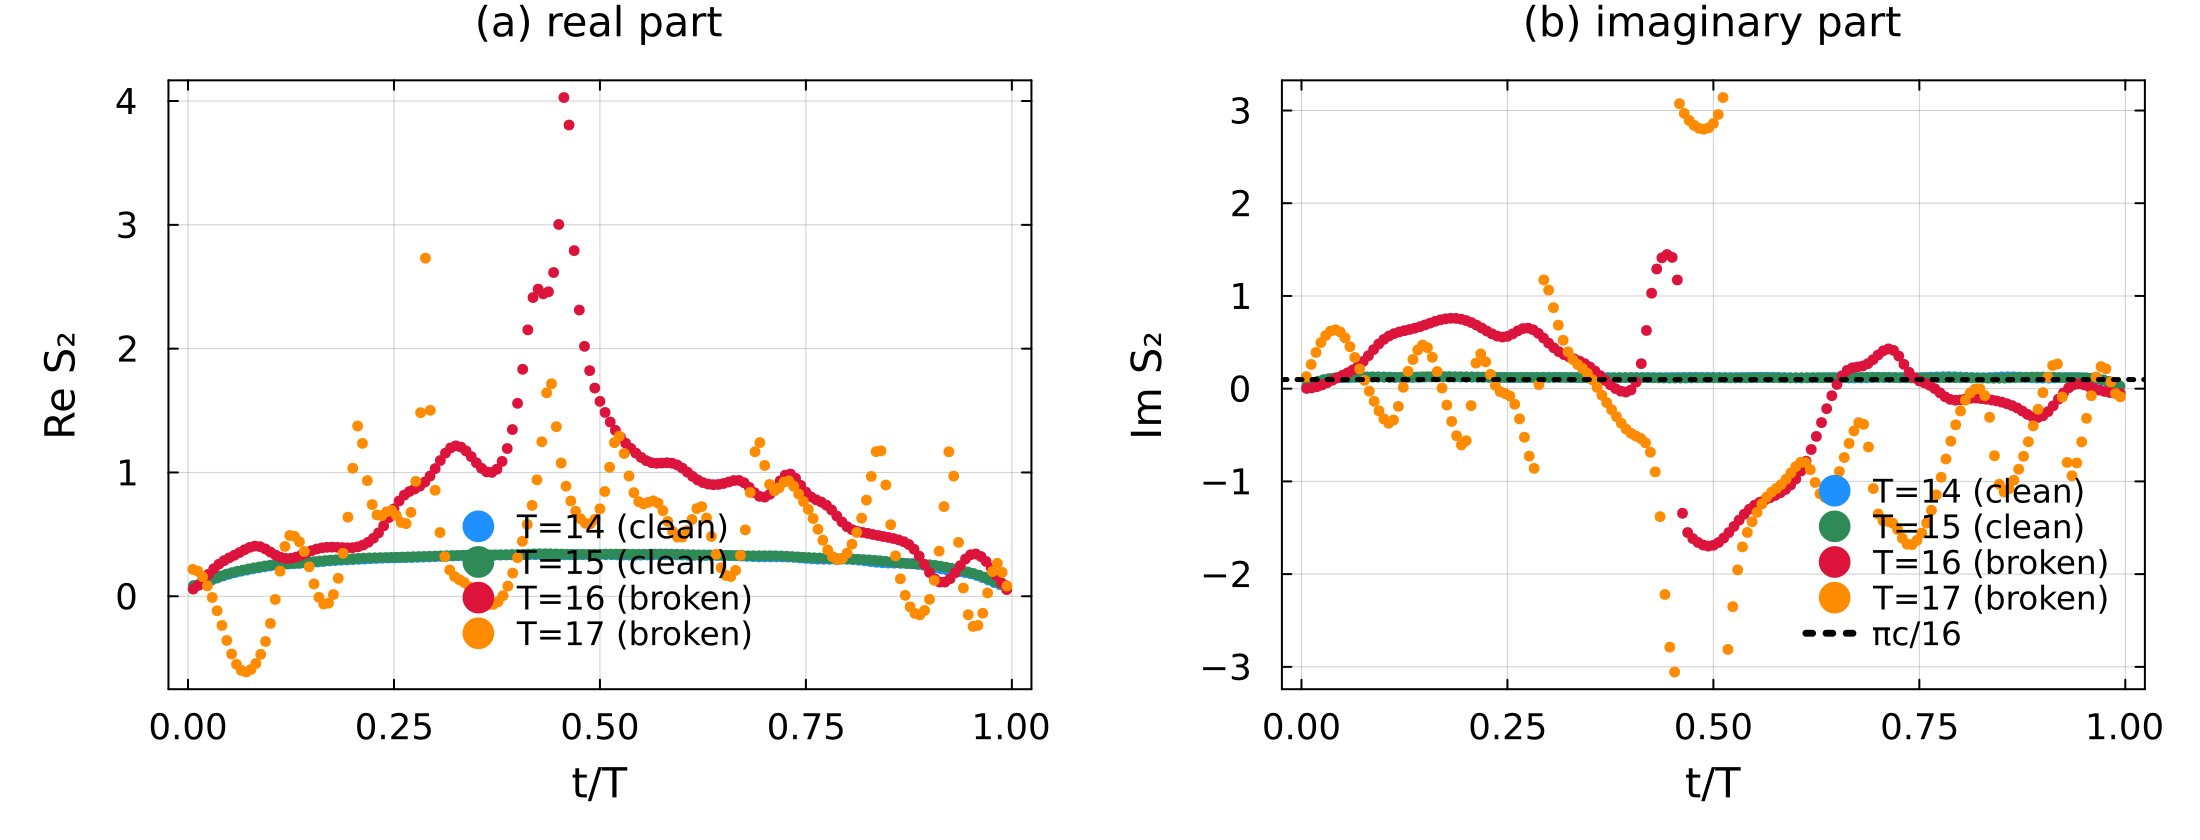

In [4]:
# clean versus broken profiles from the same cluster arm (p=0, corrected data)
arm(file, label) = Dict(k[2] => v for (k, v) in load(joinpath("../data/cluster", file), "done")
                        if k[1] == label && !haskey(v, :error) && !isempty(v.s2_base))
a0 = arm("sweep_ent_p0.0.jld2", "ent_p0.0")
avail = sort(collect(keys(a0)))
clean  = [T for T in (14.0, 15.0) if T in avail]
broken = [T for T in avail if T > 15.0][1:min(2, end)]

pa = plot(xlabel="t/T", ylabel="Re S₂", legend=:bottom, title="(a) real part")
pb = plot(xlabel="t/T", ylabel="Im S₂", legend=:bottomright, title="(b) imaginary part")
for (Tset, cols, tag) in ((clean, (:dodgerblue, :seagreen), "clean"),
                          (broken, (:crimson, :darkorange), "broken"))
    for (T, col) in zip(Tset, cols)
        s2 = a0[T].s2_base
        n = length(s2)
        ts = range(T / (n + 1), T - T / (n + 1), length=n) ./ T
        scatter!(pa, ts, real.(s2), color=col, ms=3, msw=0, label="T=$(Int(T)) ($tag)")
        scatter!(pb, ts, imag.(s2), color=col, ms=3, msw=0, label="T=$(Int(T)) ($tag)")
    end
end
hline!(pb, [pi / 32], color=:black, ls=:dot, label="πc/16")
plot(pa, pb, layout=(1, 2), size=(1100, 420), margin=5Plots.mm)

## The plateau against $T$ — and why the entropy $c$ is still open

If the plateau offset is a finite-time correction it must shrink as $T$ grows. It does — but
slowly, and the extrapolation to $T \to \infty$ is only as good as the ladder is long:

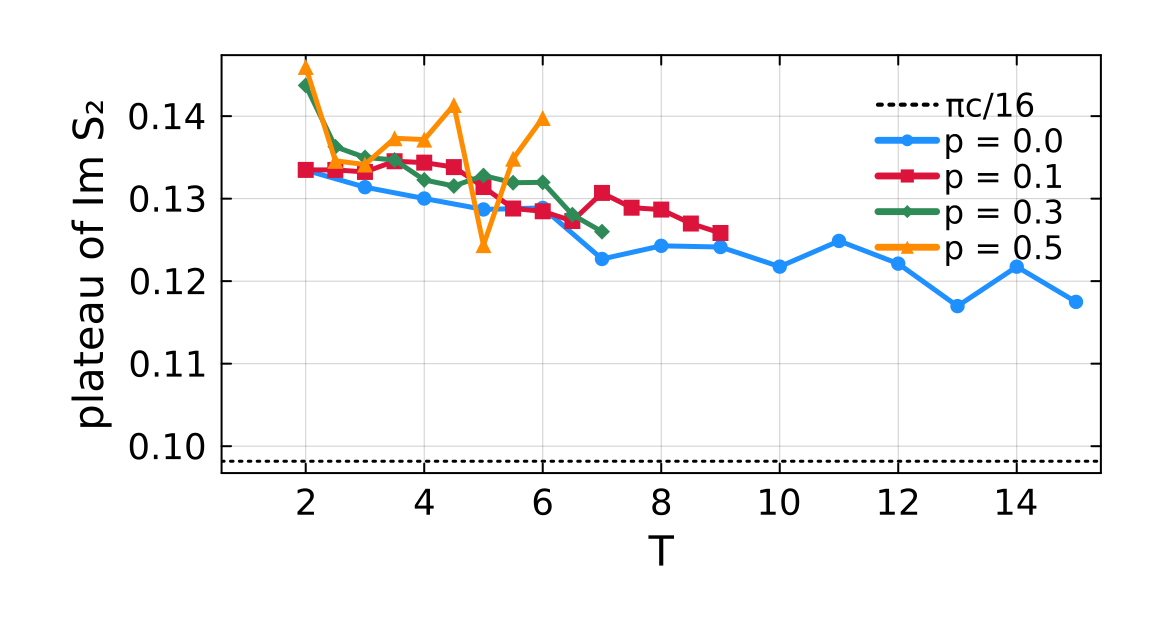

In [5]:
plateau(s2) = mean(imag.(s2)[max(1, length(s2) ÷ 2 - 1):(length(s2) ÷ 2 + 2)])
sources = [(0.0, "sweep_ent_p0.0.jld2",      "ent_p0.0"),
           (0.1, "sweep_ent_p0.1_bulk.jld2", "ent_p0.1_bulk"),
           (0.3, "sweep_ent_p0.3_bulk.jld2", "ent_p0.3_bulk"),
           (0.5, "sweep_ent_p0.5_bulk.jld2", "ent_p0.5_bulk")]
ent_max = Dict(0.0 => 15.0, 0.1 => 9.0, 0.3 => 7.0, 0.5 => 6.0)   # clean windows
pl = plot(xlabel="T", ylabel="plateau of Im S₂", legend=:topright,
          size=thesis_size(0.75; aspect=0.55))
hline!(pl, [pi / 32], color=:black, ls=:dot, lw=1.5, label="πc/16")
for (p, f, l) in sources
    a = arm(f, l)
    Ts = sort([T for T in keys(a) if T <= ent_max[p]])
    plot!(pl, Ts, [plateau(a[T].s2_base) for T in Ts], marker=P_MARKER[p], ms=4, msw=0,
          color=P_COLOR[p], label="p = $p")
end
pl

This is why the entropy column of the central-charge table is still marked `[OPEN]` in
the thesis: a plateau extrapolated from a short ladder lands *high* with a small formal error
bar — a bias, not a statistical error. Honest answer: the arms at $p \neq 0$ are not yet long
enough, and the cluster ladders keep extending. The full fit analysis (per-rung fits, the
$\beta_0$ regulator terms, and the model comparison behind the extrapolation) is
`scripts/analysis/entropy_c.jl`.

## The remaining couplings

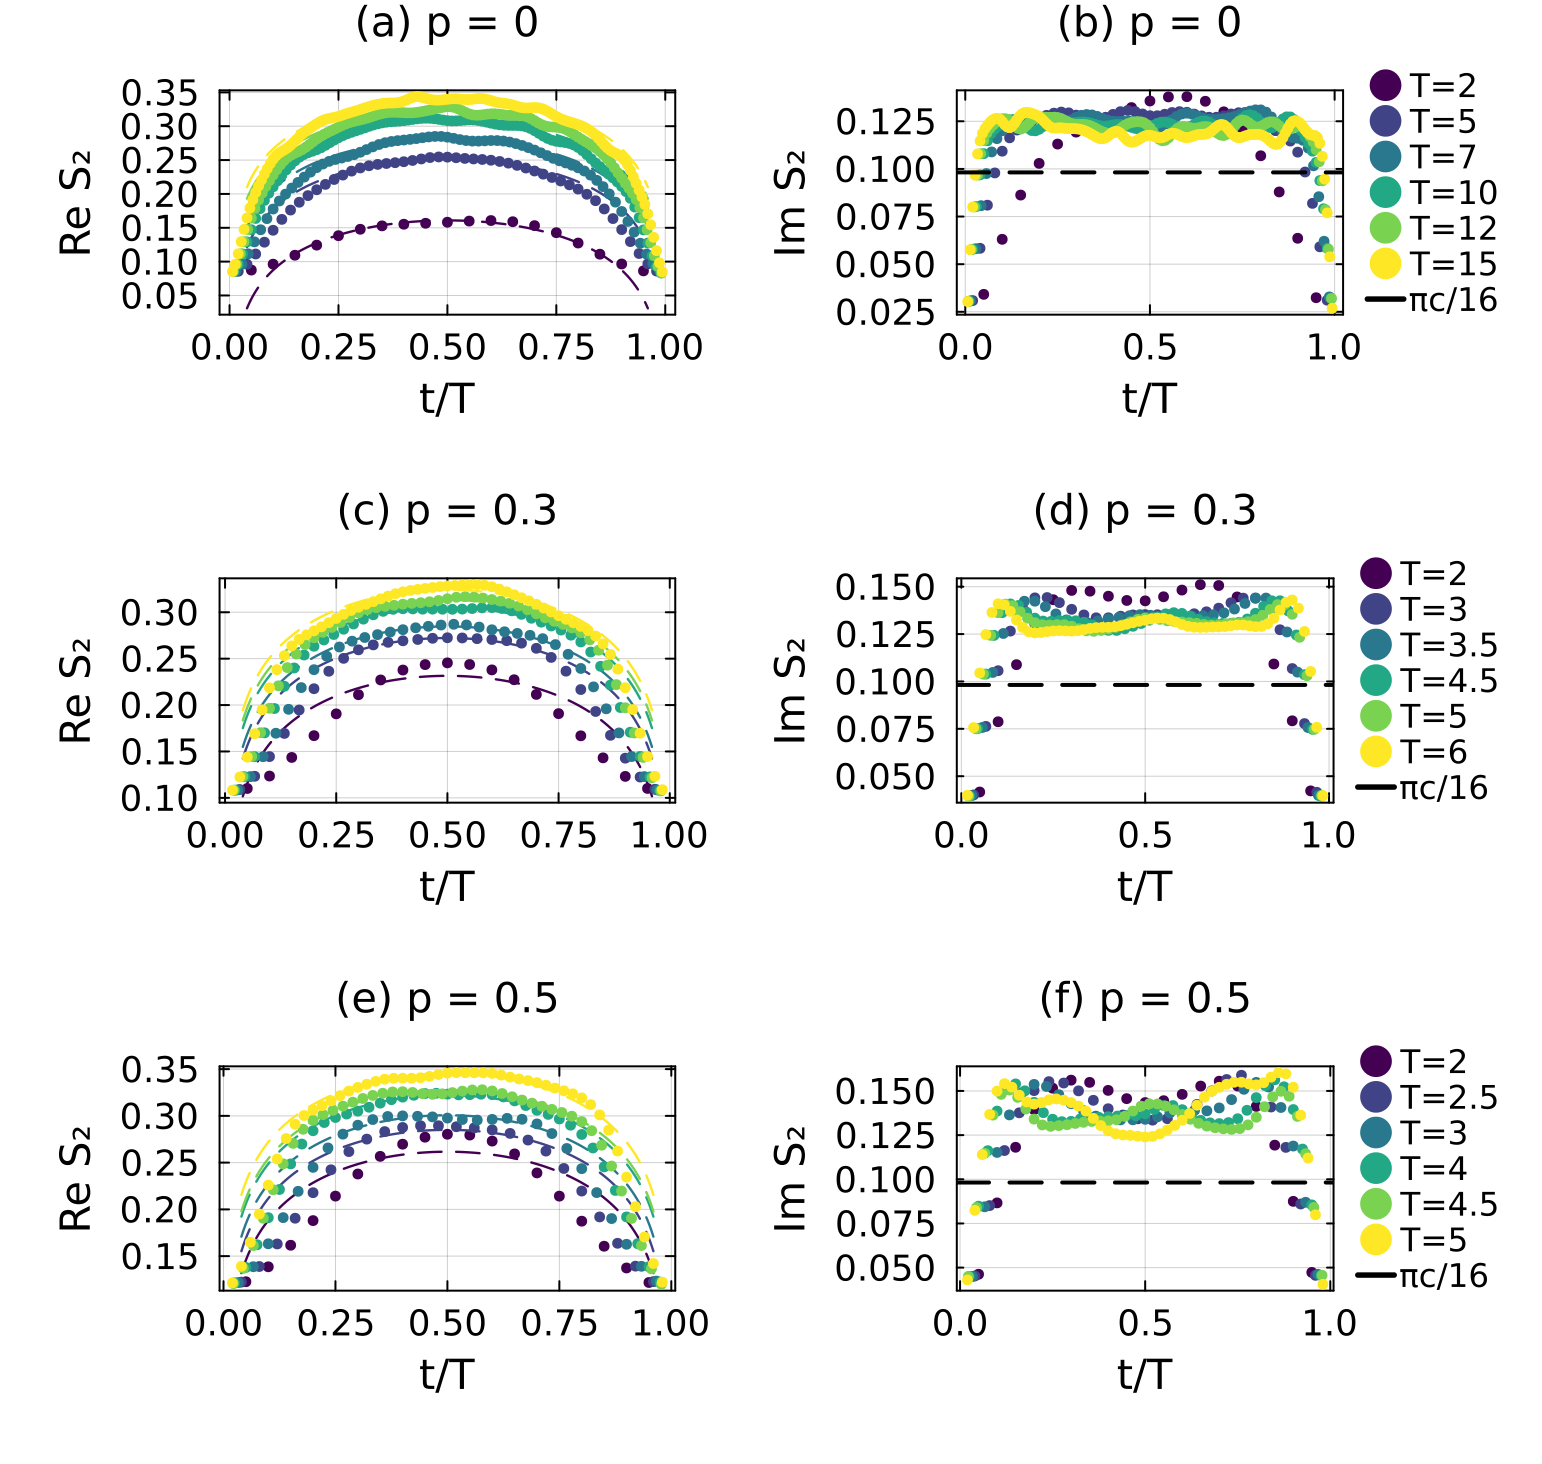

In [6]:
include("../scripts/figures/fig_domes_hi.jl")
make_domes_hi()

## Why the real part is not the estimator either

$\mathrm{Re}\,S_2$ carries $c$ in its chord slope, so one could fit it directly. The pure
logarithm overestimates $c$ (it returns $\approx 0.6$–$0.7$ even at the integrable point).
The known finite-time correction $\propto w^{-1/2}$ describes the profile — but on the
accessible window the correction and the logarithm are nearly the same regressor (correlation
$-0.9997$ on the mid-strip), so freeing $c$ on top of the correction is ill conditioned.
Pinning $c = 1/2$ with the correction matches the data from $T \approx 12$; *measuring* $c$
this way is not possible on these windows.

T=14: c_unc=0.618  c_corr=0.472  a_pin=-0.0843
c_unc range 0.304..0.785 ; c_corr range 0.450..1.372


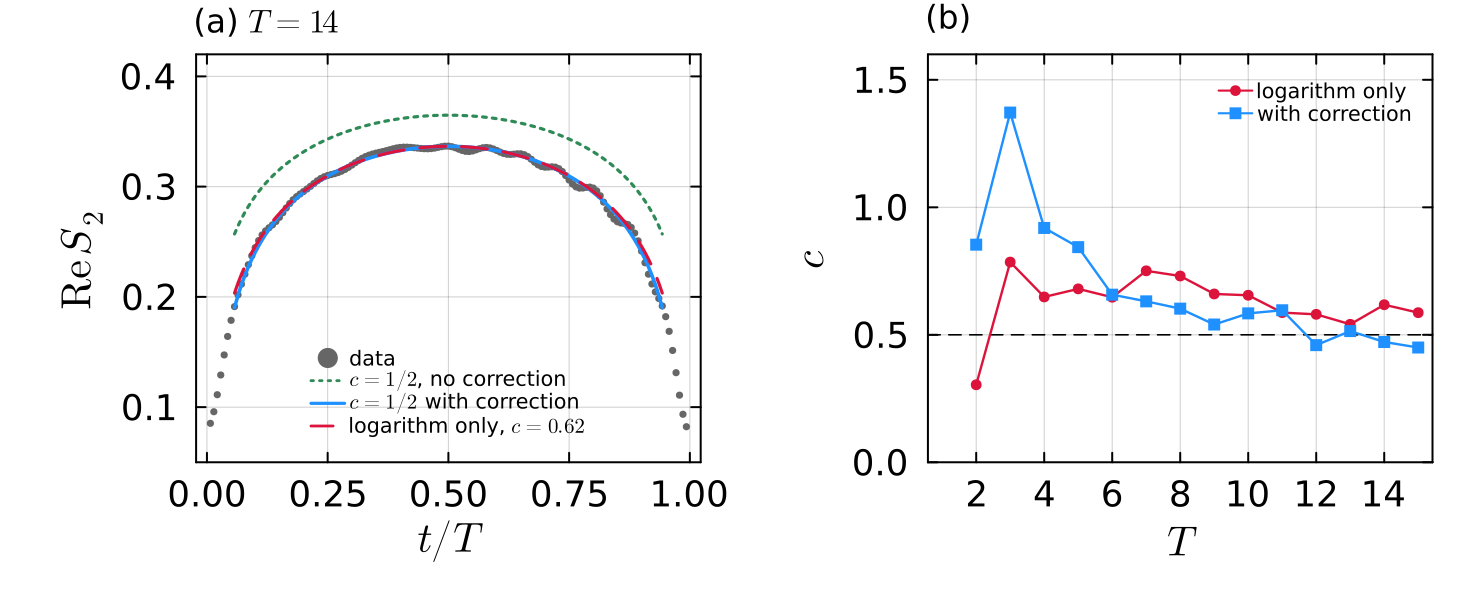

In [7]:
include("../scripts/figures/fig_re_c.jl")
make_re_c()

## Takeaways

- The temporal entropy is conformal where the contraction converges, and the wall — a physical
  gap closing, not a solver artefact — sets a coupling-dependent maximal time.
- Past the wall the profiles are visibly, qualitatively broken; no fit is attempted there.
- The plateau is the right entropy estimator of $c$, but its finite-time bias means the
  quoted values wait for longer arms (`[OPEN]` in the thesis, deliberately).
- Reliability is asymmetric: the entropy route needs eigenvectors and fails 2/10 seeds at
  $p=0.3$, $T=7$, while the eigenvalue-only spectral route (next notebook) fails 0/6 there.
  The statistics are in notebook 6.